# Difference Equations

Economists often study how economic variables move over time, such as national income, interest rates, money supply, production of oil, price of rice, and so on. Time can be treated as either discrete or continuous. A useful way to model the dynamics of variables of interest at discrete time intervals (e.g., daily, weekly, monthly, or annually) is through difference equations or recurrence relations.

## First-Order Difference Equations

The simplest dynamic models in economics assume that the value of a variable today depends linearly on its value yesterday plus some constant term. This gives us the **first-order linear difference equation**:

$$x_{t} = a x_{t-1} + c$$

where:
- $x_t$ is the value at time $t$
- $x_{t-1}$ is the value at time $t-1$ (the previous period)
- $a$ is the coefficient measuring how much past values persist
- $c$ is a constant term (often representing an external forcing variable)

:::{note}
**Key Idea**
A difference equation describes how a variable evolves **step by step over time**. Unlike differential equations (which describe continuous change), time here moves in discrete periods: $t = 0, 1, 2, \dots$

Think of it like a recipe: to know where you'll be tomorrow ($x_t$), you need to know where you are today ($x_{t-1}$) and how the system behaves ($a$ and $c$).
:::

The rest of this section explores how the parameter $a$ determines whether the system converges to a steady state, diverges to infinity, or oscillates.

### Example 1: Convergent and Monotonic

Let's start with a concrete example. Consider:

$$x_{t} = \frac{1}{2}x_{t-1} + 300$$

with starting value $x_0 = 400$.

**Calculating the first few terms:**

| $t$ | Calculation | $x_t$ |
|-----|-------------|-------|
| 0 | (given) | 400 |
| 1 | $\frac{1}{2}(400) + 300$ | 500 |
| 2 | $\frac{1}{2}(500) + 300$ | 550 |
| 3 | $\frac{1}{2}(550) + 300$ | 575 |
| 4 | $\frac{1}{2}(575) + 300$ | 587.5 |

Notice that $x_t$ increases each period, but the **increases get smaller**: 100, then 50, then 25, then 12.5. The series appears to be approaching some limiting value.

**Finding the steady state:**

The steady state (or equilibrium) is the value $x_{\infty}$ such that if the system reaches it, it stays there. That means $x_t = x_{t-1} = x_{\infty}$. Substituting into the equation:

:::{math}
:enumerated: false
x_{\infty} = \frac{1}{2}x_{\infty} + 300
:::

Solving:

:::{math}
:enumerated: false
x_{\infty} - \frac{1}{2}x_{\infty} = 300
:::

:::{math}
:enumerated: false
\frac{1}{2}x_{\infty} = 300
:::

:::{math}
:enumerated: false
x_{\infty} = 600
:::

So the series approaches 600, but never quite reaches it — it gets arbitrarily close over time.

**Characteristics of this path:**

- **Monotonic**: Because $a = 0.5 > 0$, the path moves consistently in one direction (increasing, since $x_0 < x_{\infty}$)
- **Stable (convergent)**: Because $|a| = 0.5 < 1$, the system converges to the steady state regardless of starting point

Let's visualize this behavior for multiple starting values:

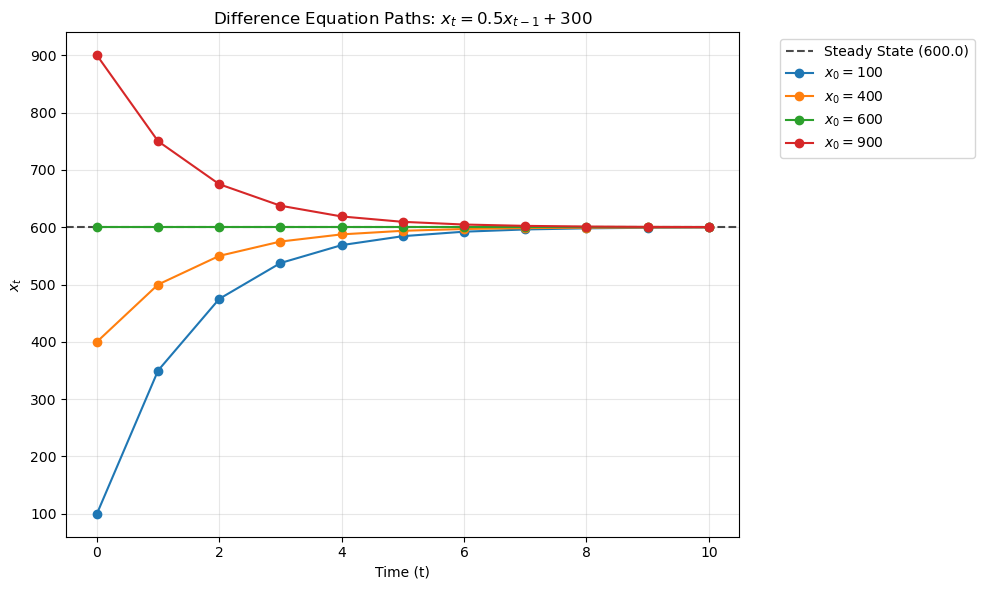

In [1]:
import matplotlib.pyplot as plt

def simulate_multiple_paths(a, c, x_starts, t=10):
    """Simulate and plot multiple paths of a first-order difference equation.
    
    Parameters:
    a : float
        Coefficient on lagged value
    c : float
        Constant term
    x_starts : list of float
        Initial values to simulate
    t : int
        Number of periods to simulate
    """
    plt.figure(figsize=(10, 6))
    
    # Calculate steady state for reference
    if a != 1:
        steady_state = c / (1 - a)
        plt.axhline(steady_state, color='black', linestyle='--', alpha=0.7, 
                    label=f'Steady State ({steady_state:.1f})')
    
    # Simulate each starting value
    for x0 in x_starts:
        path = [x0]
        for _ in range(t):
            path.append(a * path[-1] + c)
        plt.plot(path, 'o-', label=f'$x_0 = {x0}$')

    plt.title(f"Difference Equation Paths: $x_t = {a}x_{{t-1}} + {c}$")
    plt.xlabel("Time (t)")
    plt.ylabel("$x_t$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- SCENARIO 1: Stable & Monotonic ---
simulate_multiple_paths(a=0.5, c=300, x_starts=[100, 400, 600, 900])

### Example 2: Convergent and Oscillatory

Now let's introduce a negative coefficient. Consider:

$$x_{t} = -\frac{1}{2}x_{t-1} + 300$$

with $x_0 = 400$.

**Calculating the first few terms:**

| $t$ | Calculation | $x_t$ |
|-----|-------------|-------|
| 0 | (given) | 400 |
| 1 | $-\frac{1}{2}(400) + 300$ | 100 |
| 2 | $-\frac{1}{2}(100) + 300$ | 250 |
| 3 | $-\frac{1}{2}(250) + 300$ | 175 |

**Key observations:**
- The values **alternate** above and below the steady state (400 → 100 → 250 → 175)
- This happens because $a = -0.5 < 0$, which creates a "zigzag" pattern
- Despite the oscillation, the path still converges because $|a| = 0.5 < 1$

**Steady state calculation:**

:::{math}
:enumerated: false
x_{\infty} = \frac{300}{1 - (-0.5)} = \frac{300}{1.5} = 200
:::

The series oscillates around 200 while getting closer each period.

:::{tip}
**Economic Interpretation**
Stable difference equations like these often describe **gradual adjustment** processes:
- Capital accumulation (each period's capital depends on last period's, plus investment)
- Price adjustment (prices move partially toward equilibrium each period)
- Expectation updating (beliefs converge toward reality over time)
:::

Let's visualize this oscillatory convergence:

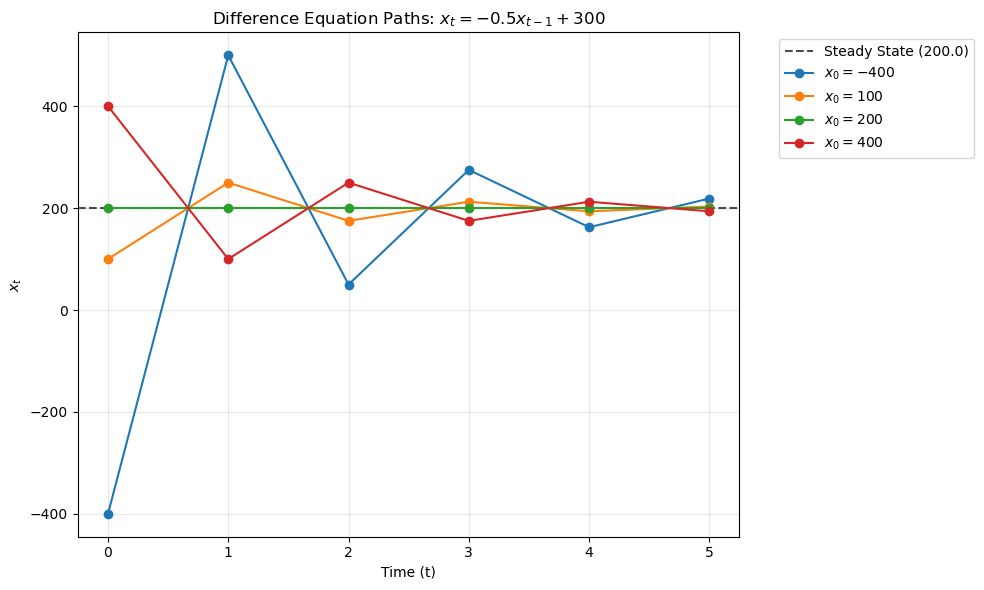

In [2]:
# --- SCENARIO 2: Stable & Oscillatory ---
simulate_multiple_paths(a=-0.5, c=300, x_starts=[-400, 100, 200, 400], t=5)

### Example 3: Divergent and Monotonic

Now let's see what happens when $|a| > 1$. Consider:

$$x_{t} = 2x_{t-1} - 300$$

with $x_0 = 400$.

**Calculating the first few terms:**

| $t$ | Calculation | $x_t$ |
|-----|-------------|-------|
| 0 | (given) | 400 |
| 1 | $2(400) - 300$ | 500 |
| 2 | $2(500) - 300$ | 700 |
| 3 | $2(700) - 300$ | 1100 |
| 4 | $2(1100) - 300$ | 1900 |

**Key observations:**
- The values **grow without bound** (diverge to $+\infty$)
- The path is **monotonic** because $a = 2 > 0$
- The steady state is $x_{\infty} = \frac{-300}{1 - 2} = \frac{-300}{-1} = 300$

**Critical insight:** Even though a steady state exists ($x_{\infty} = 300$), it is **unstable**. The system will only remain at 300 if it starts exactly there. Any deviation — no matter how small — will grow over time.

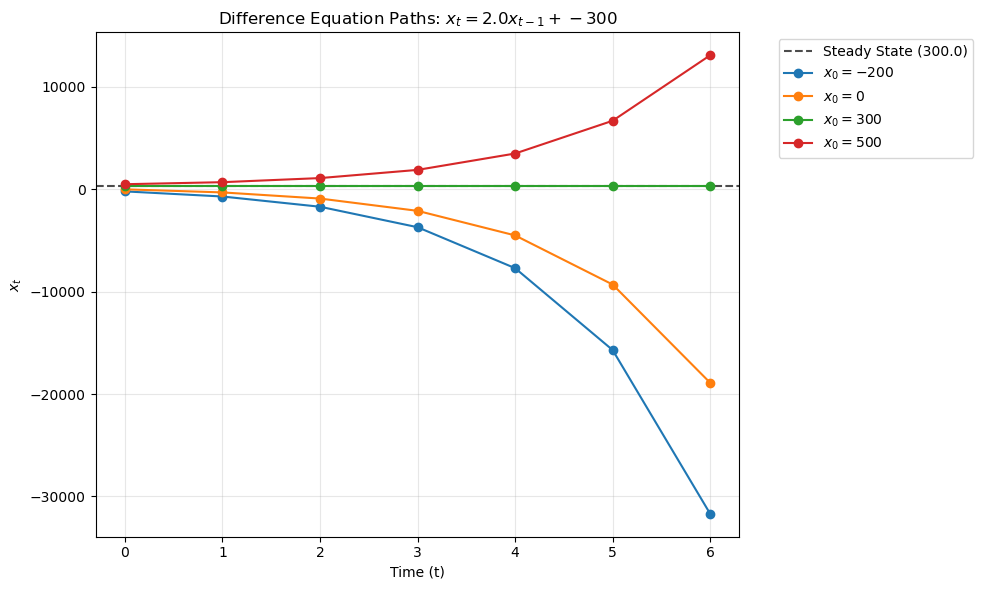

In [3]:
# --- SCENARIO 3: Unstable & Monotonic ---
simulate_multiple_paths(a=2.0, c=-300, x_starts=[-200, 0, 300, 500], t=6)

### Example 4: Divergent and Oscillatory

Now combine negative $a$ with $|a| > 1$:

$$x_{t} = -2x_{t-1} + 900$$

with $x_0 = 400$.

**Calculating the first few terms:**

| $t$ | Calculation | $x_t$ |
|-----|-------------|-------|
| 0 | (given) | 400 |
| 1 | $-2(400) + 900$ | 100 |
| 2 | $-2(100) + 900$ | 700 |
| 3 | $-2(700) + 900$ | -500 |
| 4 | $-2(-500) + 900$ | 1900 |

**Key observations:**
- The values **oscillate** (alternating signs) because $a = -2 < 0$
- The **amplitude grows** because $|a| = 2 > 1$
- The path diverges explosively

**Steady state:**

:::{math}
:enumerated: false
x_{\infty} = \frac{900}{1 - (-2)} = \frac{900}{3} = 300
:::

This steady state exists but is highly unstable — the system explodes away from it.

:::{note}
**Knife-Edge Equilibrium**
When $|a| > 1$, the steady state exists mathematically but is dynamically unstable. The system will only remain at $x^*$ if it starts there exactly. Any small deviation, no matter how tiny, will grow over time.

In economic terms, this represents a system with **increasing returns** or **positive feedback** — small perturbations amplify rather than dissipate.
:::

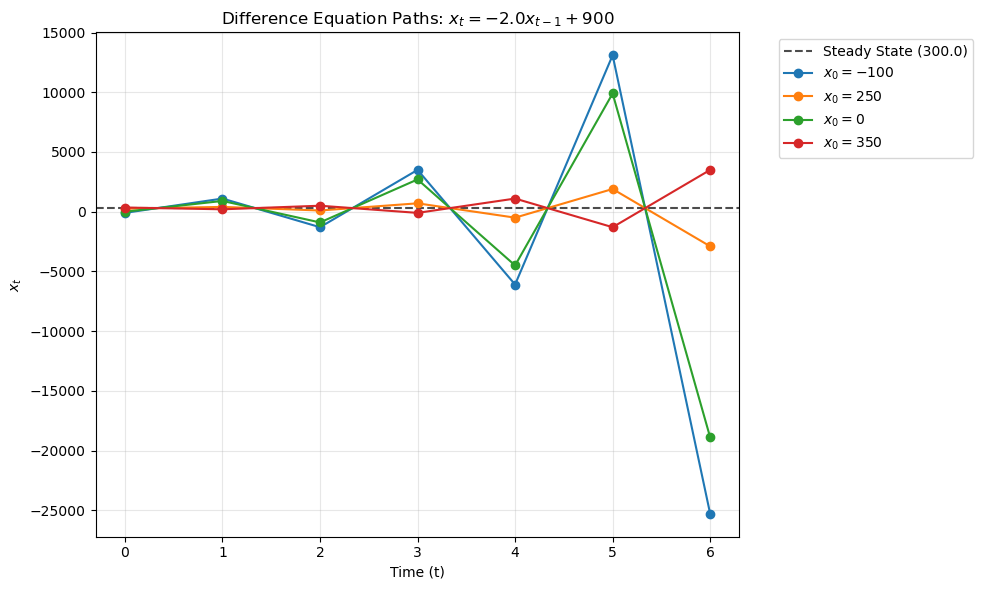

In [4]:
# --- SCENARIO 4: Unstable & Oscillatory ---
simulate_multiple_paths(a=-2.0, c=900, x_starts=[-100, 250, 0, 350], t=6)

## Summary of Stability for First-Order Equations

For the equation $x_t = a x_{t-1} + c$, the steady state is:

$$x_{\infty} = \frac{c}{1 - a} \quad (\text{for } a \neq 1)$$

The behavior of the system depends entirely on the value of $a$:

| Condition on $a$ | Path Characteristic | Stability | Visual Pattern |
|------------------|---------------------|-----------|----------------|
| $0 < a < 1$ | Monotonic | ✅ Stable (converges to $x^*$) | Smooth approach |
| $-1 < a < 0$ | Oscillatory | ✅ Stable (converges to $x^*$) | Zigzag approach |
| $a > 1$ | Monotonic | ❌ Unstable (diverges to $\pm\infty$) | Smooth explosion |
| $a < -1$ | Oscillatory | ❌ Unstable (diverges/explodes) | Oscillating explosion |
| $a = 1$ | Linear trend | ❌ Unstable ($x_t = x_0 + ct$) | Straight line |
| $a = -1$ | Fixed oscillation | ❌ Unstable (2-cycle around $x^*$) | Alternating constant |

:::{important}
**The Key Condition**
- **Stability requires $|a| < 1$**
- This means the effect of past values decays over time
- When $|a| > 1$, past effects amplify — the system is unstable
- When $|a| = 1$, the system neither decays nor explodes (special case)
:::

### Special Cases

**Case 1: $a = 1$**

The equation becomes $x_t = x_{t-1} + c$. This is a simple linear trend:

$$x_t = x_0 + tc$$

- If $c > 0$, the series increases linearly without bound
- If $c < 0$, it decreases linearly without bound
- If $c = 0$, it stays constant at $x_0$

**Case 2: $a = -1$**

The equation becomes $x_t = -x_{t-1} + c$. This creates a perfect 2-cycle:

- If $x_0 = c/2$, the system stays at the steady state
- Otherwise, it oscillates forever between two values: $x_0$ and $c - x_0$

The steady state is $x^* = c/2$, but the system never converges to it unless it starts there.

**Case 3: Multiple equilibria**

When $a = 1$ and $c = 0$, **every** value is a steady state! The system never moves regardless of where it starts.

### Solution to First-Order Difference Equation by Repeated Iteration

The following derivation demonstrates how to find the general solution for a first-order linear difference equation by repeatedly substituting the equation into itself.

Starting with the general first-order linear difference equation:

:::{math}
:label: eq-difference
x_{t} = a x_{t-1} + c
:::

Since this relationship holds for any time period, we know that for period $t-1$:

:::{math}
:label: eq-difference-1
x_{t-1} = ax_{t-2} + c
:::

**Step 1: First Substitution**

Substitute Equation {eq}`eq-difference-1` into Equation {eq}`eq-difference`:

:::{math}
:enumerated: false
x_{t} = a(ax_{t-2} + c) + c
:::

:::{math}
:enumerated: false
x_{t} = a^{2}x_{t-2} + ac + c
:::

**Step 2: Second Substitution**

We also know that $x_{t-2} = ax_{t-3} + c$. Hence sbstituting this in:

:::{math}
:enumerated: false
x_{t} = a^{2}(ax_{t-3} + c) + ac + c
:::

:::{math}
:enumerated: false
x_{t} = a^{3}x_{t-3} + a^{2}c + ac + c
:::

**Step 3: Generalizing the Pattern**


Continuing this repeated substitution $t$ times, we arrive at the general solution by iteration:

:::{math}
:enumerated: false
x_{t} = a^{t}x_{0} + a^{t-1}c + a^{t-2}c + \dots + a^{2}c + ac + c
:::

This can be written more compactly using summation notation:

:::{math}
:enumerated: false
x_{t} = a^{t}x_{0} + \sum_{i=0}^{t-1} a^{i}c
:::

**Step 4: Using the Geometric Series Formula**

The term $\sum_{i=0}^{t-1} a^{i}$ is a geometric series. It can be shown that for $a \neq 1$:

:::{math}
:enumerated: false
\sum_{i=0}^{t-1} a^{i} = \frac{1-a^{t}}{1-a}
:::

Since the constant $c$ is not affected by the summation index $i$, we have $\sum_{i=0}^{t-1} a^{i}c = c\sum_{i=0}^{t-1} a^{i}$. Substituting the series formula into our solution gives:

:::{math}
:label: defn-solution-1
x_{t} = a^{t}x_{0} + \frac{1-a^{t}}{1-a}c
:::

::: {.callout-note title="Reading the Solution"}
The solution has two parts:

- $a^t x_0$ → the effect of the **initial condition**
- the remaining terms → the effect of the **forcing term**

So the time path reflects both where the system starts and how it is pushed over time.
:::

---

### Stability and the Steady State

This solution allows us to see exactly what happens as time ($t$) goes to infinity. 

* **If $|a| < 1$**: As $t \to \infty$, the term $a^{t}$ goes to $0$. 
    The equation then simplifies to the steady state ($x_{\infty}$):
:::{math}
:enumerated: false
x_{\infty} = \lim_{t\to\infty} \left( a^{t}x_{0} + \frac{1-a^{t}}{1-a}c \right) = 0 \cdot x_{0} + \frac{1-0}{1-a}c = \frac{c}{1-a}
:::

> This confirms that when $|a| < 1$, the series is **stable** and converges to $x_{\infty}$ regardless of the starting value $x_0$.

* **If $|a| > 1$**: As $t \to \infty$, the term $a^{t}$ diverges toward $\pm\infty$. 
    In this case, the series is **unstable** and moves further away from the steady state over time (unless $x_0$ is exactly equal to the steady state value).

## General Solution to First-Order Difference Equations

The general solution can be found by combining the **complementary solution** and the **particular solution**. 

:::{math}
:enumerated: false
\text{General solution} = \text{Complementary solution} + \text{Particular solution}
:::


And as we will see later, this method is especially useful for solving higher-order equations later.

#### 1. The Complementary Solution ($x_c$)

The complementary solution is obtained by considering the **homogeneous equation**, which means setting the constant term $c$ to zero:

:::{math}
:enumerated: false
x_{t} - ax_{t-1} = 0
:::

We assume a solution of the form $x_{t} = Ak^{t}$. Substituting this into the homogeneous equation gives:

:::{math}
:enumerated: false
Ak^{t} - aAk^{t-1} = 0
:::

Dividing by $Ak^{t-1}$ gives $k = a$. Therefore, the complementary solution is:

:::{math}
:enumerated: false
x_{t} = Aa^{t}
:::

* **$A$** is a constant to be determined by initial conditions.
* This part of the function reflects the **deviation** from the steady state.

#### 2. The Particular Solution ($x_p$)

The particular solution is any solution that satisfies the non-homogeneous difference equation. It is most convenient to use the **steady state value** ($x_{\infty}$) as the particular solution. 

As derived previously, for $a \neq 1$:

:::{math}
:enumerated: false
x_{p} = \frac{c}{1 - a}
:::

* The particular solution represents the **inter-temporal equilibrium** or steady state.

::: {.callout-note title="Intuition"}
The steady state is the value of $x$ that reproduces itself over time. If the system reaches $x^*$, then $x_{t}=x_{t-1}=x^*$ and there is no further change.
:::

#### 3. The General Solution

The general solution is the sum of the complementary and particular solutions:

:::{math}
:enumerated: false
x_{t} = Aa^{t} + \frac{c}{1 - a}
:::

#### 4. The Definite Solution

To find the specific value for $A$, we use the initial condition at $t = 0$:

:::{math}
:enumerated: false
x_{0} = Aa^{0} + \frac{c}{1 - a}
:::

:::{math}
:enumerated: false
A = x_{0} - \frac{c}{1 - a}
:::

Substituting this value of $A$ back into the general solution gives the **definite solution**:

:::{math}
:enumerated: false
x_{t} = \left( x_{0} - \frac{c}{1 - a} \right) a^{t} + \frac{c}{1 - a}
:::

Which can be rearranged to match the result from the iteration method:

:::{math}
:enumerated: false
x_{t} = a^{t}x_{0} + \frac{1 - a^{t}}{1 - a}c
:::

> Note that this is exactly the same Equation {eq}`defn-solution-1` derived previously.
---

### Stability Condition

The system is considered **stable** as long as the complementary part $Aa^{t} \to 0$ as $t \to \infty$

* If **$|a| < 1$**, the time path will converge to the equilibrium (steady state).
* If **$|a| > 1$**, the time path will diverge away from the equilibrium.
* Also, if **$a = 1$**, we have $x_t = x_0 + ct$.

::: {.callout-important title="Common Pitfall"}
Do not confuse **existence of a steady state** with **stability**.

A steady state may exist even when $|a|>1$, but the system will move away from it unless the initial value is exactly equal to $x^*$.
:::

### Numerical Example

This example follows the general solution method by combining the complementary and particular solutions to find a definite solution for a specific system.

**Given Equation:**

:::{math}
:enumerated: false
x_{t} = -7x_{t-1} + 16
:::

**Initial Condition:**
:::{math}
:enumerated: false
x_{0} = 5
:::

---

### Step 1: Identify Parameters

From the general form $x_t = ax_{t-1} + c$, we identify:

* $a = -7$
* $c = 16$
* $x_0 = 5$

### Step 2: Find the Particular Solution ($x_p$)

The particular solution represents the steady state ($x_{\infty}$). For $a \neq 1$, it is calculated as:

:::{math}
:enumerated: false
x_{p} = \frac{c}{1 - a} = \frac{16}{1 - (-7)} = \frac{16}{8} = 2
:::

### Step 3: Find the Complementary Solution ($x_c$)

The complementary solution takes the form $Aa^t$. Using our value for $a$:

:::{math}
:enumerated: false
x_{c} = A(-7)^{t}
:::

### Step 4: Form the General Solution

The general solution is the sum of the complementary and particular solutions:

:::{math}
:enumerated: false
x_{t} = A(-7)^{t} + 2
:::

### Step 5: Solve for the Constant $A$ (Definite Solution)

Use the initial condition $x_0 = 5$ at $t = 0$:

:::{math}
:enumerated: false
5 = A(-7)^{0} + 2
:::

:::{math}
:enumerated: false
5 = A(1) + 2
:::

:::{math}
:enumerated: false
A = 5 - 2 = 3
:::

Substituting $A$ back into the general solution gives the **Definite Solution**:

:::{math}
:enumerated: false
x_{t} = 3(-7)^{t} + 2
:::

---

### Verification

We can verify the solution by calculating the first two terms and checking them against the original difference equation:

* **At $t=0$:** $x_0 = 3(-7)^0 + 2 = 5$ (Matches initial condition).
* **At $t=1$:** $x_1 = 3(-7)^1 + 2 = -21 + 2 = -19$.

Now, substitute $x_0 = 5$ into the original difference equation to see if it produces $x_1 = -19$:

:::{math}
:enumerated: false
x_1 = -7(5) + 16 = -35 + 16 = -19
:::

The values match, confirming the solution is correct.

### Stability Analysis

Because $|a| = |-7| = 7$, which is **greater than 1**, the time path is **unstable** and will diverge. Additionally, because $a < 0$, the path will be **oscillatory**, jumping between positive and negative deviations from the steady state.

### Stability Conditions

We know have learnt that the difference equation of the form

:::{math}
:enumerated: false
x_t = a x_{t-1} + c
:::

has as its solution

:::{math}
:enumerated: false
x_t = \left( x_0 - \frac{1}{1 - a} \right) a^t + \frac{1}{1 - a} c
:::

which can be seen as essentially made up of two parts:

That is

:::{math}
:enumerated: false
\left( x_0 - \frac{1}{1 - a} \right) = A \quad \text{and} \quad \frac{1}{1 - a} c = p,
::::

and hence we have a general form $x_t = A a^t + p$.

Needless to say,

:::{math}
:enumerated: false
A = \left( x_0 - \frac{1}{1 - a} \right)
:::

forms the complementary function reflecting the deviation from equilibrium or the steady state, while

:::{math}
:enumerated: false
p = \frac{1}{1 - a} c
:::

the particular function represents the inter-temporal equilibrium level of $x_t$.

Hence, the system is stable as long as $A a^t \to 0$ as $t \to \infty$ (so the dynamics of the system depends on $a$.

Assuming $A = 1$ and $p = 0$ for now, $a^t$ will generate seven different paths depending on $a$.

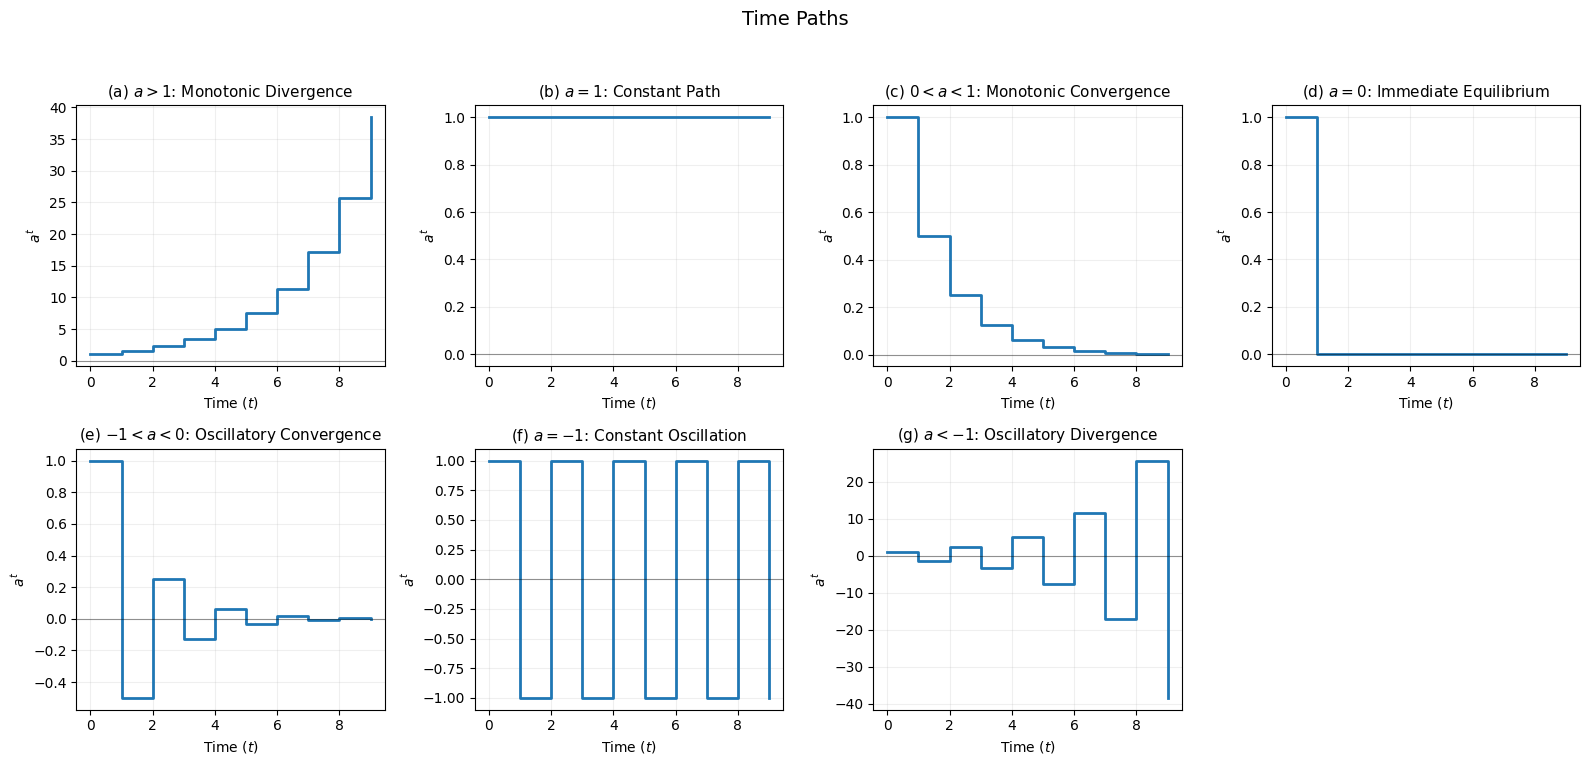

In [5]:
import numpy as np
import matplotlib.pyplot as plt

a_values = [1.5, 1, 0.5, 0, -0.5, -1, -1.5]
titles = [
    "(a) $a > 1$: Monotonic Divergence",
    "(b) $a = 1$: Constant Path",
    "(c) $0 < a < 1$: Monotonic Convergence",
    "(d) $a = 0$: Immediate Equilibrium",
    "(e) $-1 < a < 0$: Oscillatory Convergence",
    "(f) $a = -1$: Constant Oscillation",
    "(g) $a < -1$: Oscillatory Divergence"
]

n = np.arange(0, 10)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, a in enumerate(a_values):
    y = a**n
    
    # Removed 'o' from the format string to get rid of dots
    axes[i].plot(n, y, '-', drawstyle='steps-post', linewidth=2)
    
    axes[i].set_title(titles[i], fontsize=11)
    axes[i].set_xlabel("Time ($t$)")
    axes[i].set_ylabel("$a^t$")
    axes[i].axhline(0, color='black', lw=0.8, alpha=0.4)
    axes[i].grid(True, alpha=0.2)

axes[-1].axis('off')
plt.suptitle("Time Paths", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

On the y-axis we have $a^t$ and on the x-axis we have $t$.

**In sum**
- If $|a| > 1$, the time path will diverge  
- If $|a| < 1$, the time path will converge to equilibrium  

**Also**
- If $a < 0$, the time path will oscillate  
- If $a > 0$, the time path will not oscillate  

**Scaling and Shifts**
- If $A \neq 1$, the diagram shown above will simply scale up/down depending on the magnitude of $a^t$. The pattern will remain essentially the same.  
- If $A = -1$, we will get a mirror image with respect to the horizontal axis.  
- If $c \neq 0$, the vertical intercept is affected (graph shifts up/down).  

## Phase Diagrams

Time path plots (like those above) show how a variable evolves period by period. But there's another powerful visualization tool: the **phase diagram**.

A phase diagram plots $x_t$ against $x_{t-1}$, showing the relationship between consecutive periods. It includes two key elements:

1. **The 45-degree line** ($x_t = x_{t-1}$): points where the variable doesn't change
2. **The function line** ($x_t = f(x_{t-1})$): the actual relationship defined by the difference equation

The **steady state** occurs where these two lines intersect — where today's value equals yesterday's.

:::{note}
**Why Phase Diagrams Are Useful**
- They show the **direction of movement** at a glance
- They help visualize **stability** (whether paths move toward or away from equilibrium)
- They're essential for understanding **nonlinear** difference equations, where explicit solutions are hard to find
:::

The "cobweb" path (the staircase pattern) shows how the system moves:
- **Vertical moves**: apply the function $f$ to go from $x_{t-1}$ to $x_t$
- **Horizontal moves**: project back to the 45-degree line to prepare for the next period

Let's see how this works with concrete examples.

### Phase Diagram: Convergent Monotonic ($a = 0.5$)

Let's revisit our stable monotonic example: $x_t = 0.5x_{t-1} + 300$ with $x_0 = 400$.

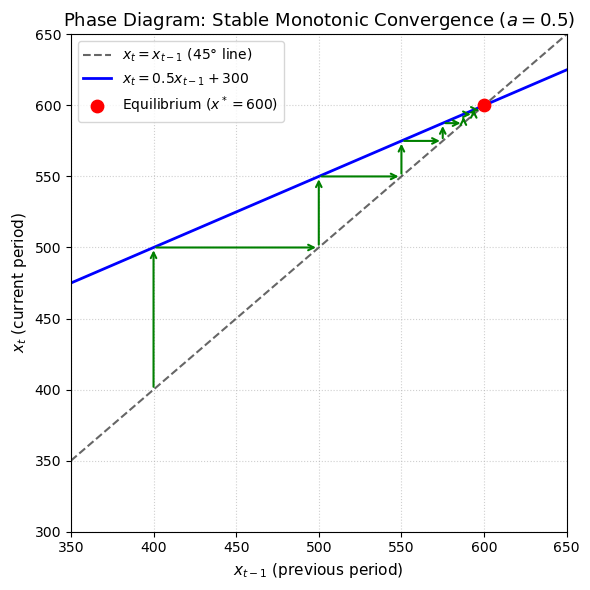

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a, c, x0 = 0.5, 300, 400
f = lambda x: a * x + c
x_star = c / (1 - a)   # equilibrium point

# Range for plotting
x_vals = np.linspace(350, 650, 200)

# Generate cobweb path
steps = 6
path_x, path_y = [x0], [x0]
for _ in range(steps):
    # Vertical move: apply the function
    path_x.append(path_x[-1])
    path_y.append(f(path_x[-1]))
    # Horizontal move: project to the 45-degree line
    path_x.append(path_y[-1])
    path_y.append(path_y[-1])

# Create the plot
plt.figure(figsize=(6,6))

# Main lines
plt.plot(x_vals, x_vals, 'k--', alpha=0.6, label=r"$x_t = x_{t-1}$ (45° line)")
plt.plot(x_vals, f(x_vals), 'b', lw=2, label=r"$x_t = 0.5x_{t-1} + 300$")

# Cobweb path with arrows
for i in range(1, len(path_x)):
    plt.annotate("",
                 xy=(path_x[i], path_y[i]),
                 xytext=(path_x[i-1], path_y[i-1]),
                 arrowprops=dict(arrowstyle="->", color="green", lw=1.5))

# Equilibrium point
plt.scatter(x_star, x_star, color='red', s=80, zorder=5,
            label=f"Equilibrium ($x^*={int(x_star)}$)")

# Formatting
plt.title(f"Phase Diagram: Stable Monotonic Convergence ($a={a}$)", fontsize=13)
plt.xlabel("$x_{t-1}$ (previous period)", fontsize=11)
plt.ylabel("$x_t$ (current period)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.xlim(350, 650)
plt.ylim(300, 650)

plt.tight_layout()
plt.show()

### Phase Diagram: Convergent Oscillatory ($a = -0.5$)

Now let's visualize the oscillatory case: $x_t = -0.5x_{t-1} + 300$ with $x_0 = 400$.

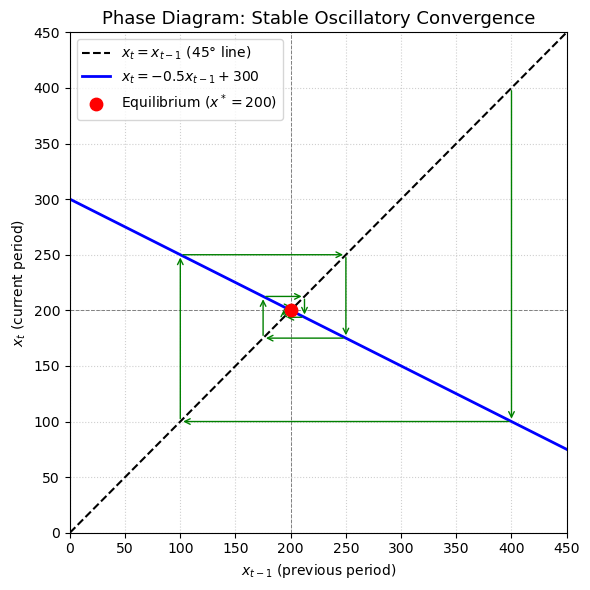

In [6]:
# Parameters
a, c, x0 = -0.5, 300, 400
f = lambda x: a * x + c
x_star = c / (1 - a)   # equilibrium point

# Range for plotting
x_vals = np.linspace(0, 450, 200)

# Generate cobweb path
steps = 6
path_x, path_y = [x0], [x0]
for _ in range(steps):
    path_x.append(path_x[-1])
    path_y.append(f(path_x[-1]))
    path_x.append(path_y[-1])
    path_y.append(path_y[-1])

# Create the plot
plt.figure(figsize=(6,6))

# Main lines
plt.plot(x_vals, x_vals, 'k--', label=r"$x_t = x_{t-1}$ (45° line)")
plt.plot(x_vals, f(x_vals), 'b-', lw=2, label=r"$x_t = -0.5x_{t-1} + 300$")

# Cobweb path with arrows
for i in range(1, len(path_x)):
    plt.annotate("",
                 xy=(path_x[i], path_y[i]),
                 xytext=(path_x[i-1], path_y[i-1]),
                 arrowprops=dict(arrowstyle="->", color="green"))

# Equilibrium point
plt.scatter(x_star, x_star, color='red', s=80, zorder=5,
            label=f"Equilibrium ($x^*={int(x_star)}$)")

# Reference lines
plt.axhline(x_star, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(x_star, color='gray', linestyle='--', linewidth=0.7)

# Formatting
plt.title("Phase Diagram: Stable Oscillatory Convergence", fontsize=13)
plt.xlabel(r"$x_{t-1}$ (previous period)")
plt.ylabel(r"$x_t$ (current period)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlim(0, 450)
plt.ylim(0, 450)
plt.tight_layout()
plt.show()

### Phase Diagram: Divergent Monotonic ($a = 2$)

Now let's visualize unstable behavior: $x_t = 2x_{t-1} - 300$ with $x_0 = 400$.

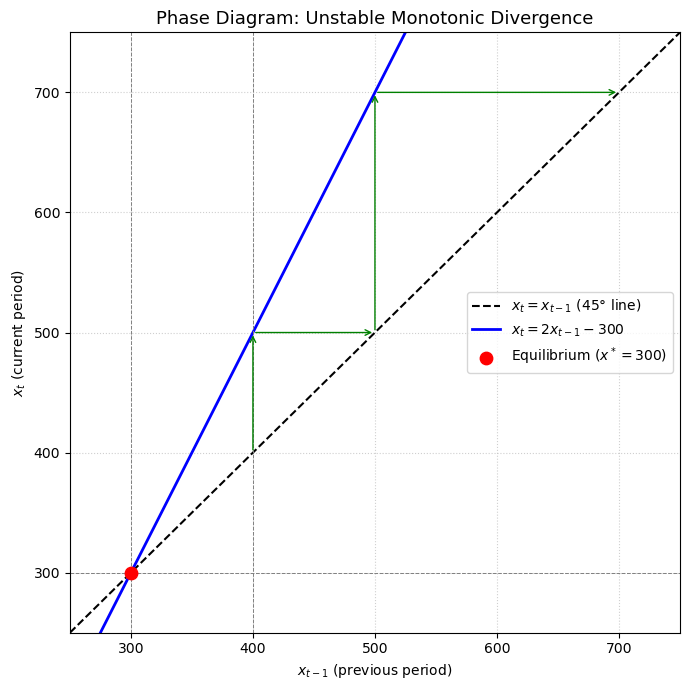

In [7]:
# Parameters
a, c, x0 = 2, -300, 400
f = lambda x: a * x + c
x_star = c / (1 - a)   # equilibrium point

# Range for plotting
x_vals = np.linspace(250, 750, 200)

# Generate cobweb path
steps = 5
path_x, path_y = [x0], [x0]
for _ in range(steps):
    path_x.append(path_x[-1])
    path_y.append(f(path_x[-1]))
    path_x.append(path_y[-1])
    path_y.append(path_y[-1])

# Create the plot
plt.figure(figsize=(7,7))

# Main lines
plt.plot(x_vals, x_vals, 'k--', label=r"$x_t = x_{t-1}$ (45° line)")
plt.plot(x_vals, f(x_vals), 'b-', lw=2, label=r"$x_t = 2x_{t-1} - 300$")

# Cobweb path with arrows
for i in range(1, len(path_x)):
    plt.annotate("",
                 xy=(path_x[i], path_y[i]),
                 xytext=(path_x[i-1], path_y[i-1]),
                 arrowprops=dict(arrowstyle="->", color="green"))

# Equilibrium point
plt.scatter(x_star, x_star, color='red', s=80, zorder=5,
            label=f"Equilibrium ($x^*={int(x_star)}$)")

# Reference lines
plt.axhline(x_star, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(x_star, color='gray', linestyle='--', linewidth=0.7)
plt.axvline(x0, color='gray', linestyle='--', linewidth=0.7)

# Formatting
plt.title("Phase Diagram: Unstable Monotonic Divergence", fontsize=13)
plt.xlabel(r"$x_{t-1}$ (previous period)")
plt.ylabel(r"$x_t$ (current period)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlim(250, 750)
plt.ylim(250, 750)
plt.tight_layout()
plt.show()

:::{tip}
Rule of thumb:

Positive slope (a>0) → monotonic movement (no sign changes)

Negative slope (a<0) → oscillatory movement (alternating signs)
:::

### Phase Diagram: Divergent Oscillatory ($a = -2$)

Finally, let's visualize unstable oscillatory behavior: $x_t = -2x_{t-1} + 900$ with $x_0 = 400$.

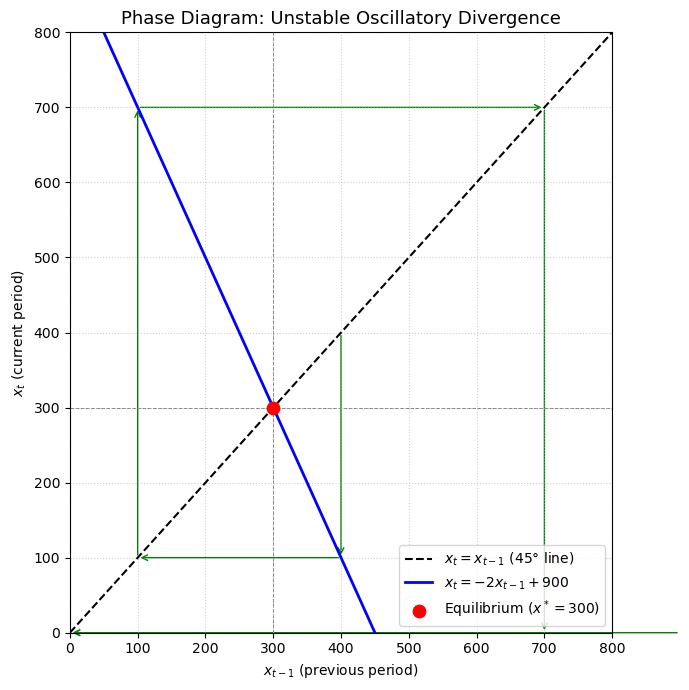

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a, c, x0 = -2, 900, 400
f = lambda x: a * x + c
x_star = c / (1 - a)   # equilibrium point

# Range for plotting
x_vals = np.linspace(0, 800, 400)

# Generate cobweb path
steps = 6
path_x, path_y = [x0], [x0]
for _ in range(steps):
    path_x.append(path_x[-1])
    y_val = f(path_x[-1])
    # Clip at 0 for visualization (prevents extreme negative values)
    path_y.append(max(y_val, 0))
    path_x.append(path_y[-1])
    path_y.append(path_y[-1])

# Create the plot
plt.figure(figsize=(7,7))

# Main lines
plt.plot(x_vals, x_vals, 'k--', label=r"$x_t = x_{t-1}$ (45° line)", zorder=2)
plt.plot(x_vals, f(x_vals), 'b-', lw=2, label=r"$x_t = -2x_{t-1} + 900$", zorder=2)

# Cobweb path with arrows
for i in range(1, len(path_x)):
    plt.annotate("",
                 xy=(path_x[i], path_y[i]),
                 xytext=(path_x[i-1], path_y[i-1]),
                 arrowprops=dict(arrowstyle="->", color="green"),
                 zorder=1)

# Equilibrium point
plt.scatter(x_star, x_star, color='red', s=80, zorder=3,
            label=f"Equilibrium ($x^*={int(x_star)}$)")

# Reference lines
plt.axhline(x_star, color='gray', linestyle='--', linewidth=0.7, zorder=1)
plt.axvline(x_star, color='gray', linestyle='--', linewidth=0.7, zorder=1)

# Formatting
plt.title("Phase Diagram: Unstable Oscillatory Divergence", fontsize=13)
plt.xlabel(r"$x_{t-1}$ (previous period)")
plt.ylabel(r"$x_t$ (current period)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlim(0, 800)
plt.ylim(0, 800)

plt.tight_layout()
plt.show()

:::{important}
Stability condition for slope:

If ∣a∣<1, the function line is flatter than 45° → stable

If ∣a∣>1, the function line is steeper than 45° → unstable

If ∣a∣=1, the function line is parallel to 45° → neutral (special case)
:::

:::{note}
# Summary: What Phase Diagrams Teach Us

| Slope Range     | Stable Behavior           | Unstable Behavior          |
|-----------------|---------------------------|----------------------------|
| 0 < a < 1       | Staircase to equilibrium  | N/A                        |
| a > 1           | N/A                       | Exploding staircase        |
| -1 < a < 0      | Spiraling inward          | N/A                        |
| a < -1          | N/A                       | Exploding outward spiral   |

The **45° line** serves as our reference — it’s where the system would stand still.  
The function line’s slope relative to 45° determines everything about the dynamics.
:::

## Second-Order Difference Equations

First-order equations capture dynamics where today's value depends only on yesterday's. But many economic processes have **longer memory** — today's value may depend on both yesterday and the day before.

Consider:
- **Inflation expectations**: people may look at inflation from both the last month and the month before
- **Business cycles**: output may depend on both last quarter's output and the quarter before that
- **Asset prices**: momentum and mean-reversion can both matter

The general second-order linear difference equation is:

$$x_t = a x_{t-1} + b x_{t-2} + c$$

where:
- $x_t$ is the value at time $t$
- $x_{t-1}$ and $x_{t-2}$ are the values at the previous two periods
- $a$ and $b$ are coefficients (weights on past values)
- $c$ is a constant term

:::{note}
**Why Second-Order?**
Second-order equations can generate richer dynamics than first-order equations:
- **Oscillations** (like business cycles)
- **Damped oscillations** (cycles that fade away)
- **Explosive oscillations** (cycles that grow)
- **Complex behavior** that first-order equations cannot produce

The key is that with two lags, the system can "overshoot" and then correct.
:::

To solve second-order equations, we follow the same strategy as before: find the **particular solution** (steady state) and the **complementary solution** (homogeneous part), then add them together.

---

### Particular Solution (Steady State)

The particular solution is the long-run equilibrium value $x_\infty$ where the system stops changing: $x_t = x_{t-1} = x_{t-2} = x_\infty$.

Substituting into the general equation:

:::{math}
:enumerated: false
x_\infty = a x_\infty + b x_\infty + c
:::

Factor $x_\infty$ on the right:

:::{math}
:enumerated: false
x_\infty = (a + b)x_\infty + c
:::

Bring the $x_\infty$ terms together:

:::{math}
:enumerated: false
x_\infty - (a + b)x_\infty = c
:::

:::{math}
:enumerated: false
x_\infty(1 - a - b) = c
:::

Therefore:

:::{math}
:enumerated: false
x_\infty = \frac{c}{1 - a - b}
:::

:::{warning}
**Special case:** If $a + b = 1$, the denominator is zero. Then:
- If $c = 0$, **every** value is a steady state (the system doesn't move)
- If $c \neq 0$, **no** finite steady state exists (the system trends)
:::

---

### Complementary Solution (Homogeneous Case)

Now we solve the homogeneous equation (setting $c = 0$):

:::{math}
:enumerated: false
x_t - a x_{t-1} - b x_{t-2} = 0
:::

We look for solutions of the form $x_t = A k^t$. Substituting:

:::{math}
:enumerated: false
A k^t - a A k^{t-1} - b A k^{t-2} = 0
:::

Factor out $A k^{t-2}$:

:::{math}
:enumerated: false
A k^{t-2}(k^2 - a k - b) = 0
:::

Since $A \neq 0$ and $k^{t-2} \neq 0$, we get the **characteristic equation**:

:::{math}
:enumerated: false
k^2 - a k - b = 0
:::

This is the key to understanding the dynamics. The roots of this quadratic equation determine everything about how the system behaves.

:::{tip}
**The Characteristic Equation**
Just as $a$ determined everything for first-order equations, the roots $k_1$ and $k_2$ of $k^2 - a k - b = 0$ determine everything for second-order equations:

- **Real roots** → monotonic or smoothly changing behavior
- **Complex roots** → oscillatory behavior
- **Repeated root** → a special "borderline" case
:::

---

### The Characteristic Roots

The quadratic formula gives:

:::{math}
:enumerated: false
k_{1,2} = \frac{a \pm \sqrt{a^2 + 4b}}{2}
:::

Alternatively, to better see the pattern:

:::{math}
:enumerated: false
k_{1,2} = \frac{a}{2} \pm \sqrt{\frac{a^2}{4} + b}
:::

The sign and value of the discriminant $a^2 + 4b$ determines which case we're in.

### The Three Cases

Depending on the discriminant $\Delta = a^2 + 4b$, we get three fundamentally different types of behavior.

---

#### Case 1: Real and Distinct Roots ($a^2 + 4b > 0$, $k_1 \neq k_2$)

When the discriminant is positive, the characteristic equation has two different real roots.

**Solution form:**
$$x_t = A k_1^t + B k_2^t$$

where $A$ and $B$ are constants determined by initial conditions.

**Behavior:**
- The system evolves as a weighted sum of two exponential terms
- The **dominant root** (largest $|k|$) determines long-run behavior
- If both $|k_1| < 1$ and $|k_2| < 1$, the system converges
- If either $|k| > 1$, the system diverges

**Example:** $a = 5$, $b = -6$ gives $k_1 = 2$, $k_2 = 3$ → divergent

---

#### Case 2: Repeated Root ($a^2 + 4b = 0$, $k_1 = k_2 = a/2$)

When the discriminant is zero, we get a single repeated root.

**Solution form:**
$$x_t = (A + B t) k_1^t$$

where $A$ and $B$ are constants determined by initial conditions.

**Behavior:**
- The $t k_1^t$ term creates a linear trend multiplied by the root
- If $|k_1| < 1$, the system still converges (the $t$ factor doesn't overcome exponential decay)
- If $|k_1| = 1$, the system grows linearly (borderline case)
- If $|k_1| > 1$, the system diverges faster than simple exponential

**Example:** $a = 0.4$, $b = -0.04$ gives $k_{1,2} = 0.2$ (repeated)

---

#### Case 3: Complex Roots ($a^2 + 4b < 0$)

When the discriminant is negative, the roots are complex conjugates:

$$k_{1,2} = r(\cos \theta \pm i \sin \theta)$$

where:
- $r = \sqrt{|b|}$ is the **modulus** (magnitude)
- $\theta = \arccos\left(\frac{a}{2r}\right)$ is the **angle** (determines oscillation frequency)

**Solution form:**
$$x_t = A r^t \cos(t\theta + \omega)$$

where $A$ and $\omega$ are constants determined by initial conditions.

**Behavior:**
- The system **oscillates** because of the cosine term
- The **amplitude decays** if $r < 1$ (convergent oscillations)
- The **amplitude grows** if $r > 1$ (divergent oscillations)
- The **frequency** of oscillations is determined by $\theta$

:::{important}
**Stability Conditions for Second-Order Equations**

| Case | Stability Condition | Behavior |
|------|---------------------|----------|
| Real roots | Both $|k_1| < 1$ and $|k_2| < 1$ | Convergent (stable) |
| Real roots | Any $|k| > 1$ | Divergent (unstable) |
| Repeated root | $|k_1| < 1$ | Convergent |
| Repeated root | $|k_1| \ge 1$ | Divergent or borderline |
| Complex roots | $r < 1$ | Oscillatory convergence |
| Complex roots | $r > 1$ | Oscillatory divergence |

**The intuitive rule:** For stability, all roots must lie **inside the unit circle** in the complex plane ($|k| < 1$ for reals, $r < 1$ for complex).
:::

---

### Summary Table

:::{math}
:enumerated: false
\begin{array}{|c|c|c|c|}
\hline
\text{Case} & \text{Condition} & \text{Solution Form} & \text{Plus } x_\infty \\
\hline
\text{Real, distinct} & a^2 + 4b > 0 & x_t = A k_1^t + B k_2^t & + x_\infty \\
\text{Repeated} & a^2 + 4b = 0 & x_t = (A + Bt) k_1^t & + x_\infty \\
\text{Complex} & a^2 + 4b < 0 & x_t = A r^t \cos(t\theta + \omega) & + x_\infty \\
\hline
\end{array}
:::

### Worked Example 1: Real Distinct Roots

Let's solve a concrete second-order equation from start to finish.

**Given:**
$$x_t - 10x_{t-1} + 16x_{t-2} = 14$$

**Initial conditions:** $x_0 = 10$, $x_1 = 36$

**Step 1: Rearrange into standard form**

First, get the equation into the form $x_t = a x_{t-1} + b x_{t-2} + c$:

:::{math}
:enumerated: false
x_t = 10x_{t-1} - 16x_{t-2} + 14
:::

So $a = 10$, $b = -16$, $c = 14$. (Note: $b$ is negative because we moved $+16x_{t-2}$ to the right side.)

**Step 2: Find the particular solution (steady state)**

:::{math}
:enumerated: false
x_\infty = \frac{c}{1 - a - b} = \frac{14}{1 - 10 - (-16)} = \frac{14}{1 - 10 + 16} = \frac{14}{7} = 2
:::

So the steady state is $x_\infty = 2$.

**Step 3: Find the characteristic equation**

:::{math}
:enumerated: false
k^2 - a k - b = k^2 - 10k - (-16) = k^2 - 10k + 16 = 0
:::

**Step 4: Solve for the roots**

:::{math}
:enumerated: false
k_{1,2} = \frac{10 \pm \sqrt{100 - 64}}{2} = \frac{10 \pm \sqrt{36}}{2} = \frac{10 \pm 6}{2}
:::

:::{math}
:enumerated: false
k_1 = \frac{10 + 6}{2} = 8,\qquad k_2 = \frac{10 - 6}{2} = 2
:::

Since $k_1 = 8$ and $k_2 = 2$ are **real and distinct**, we use Case 1.


**Step 5: Write the general solution**

:::{math}
:enumerated: false
x_t = A(2)^t + B(8)^t + 2
:::

**Step 6: Apply initial conditions**

At $t = 0$:

:::{math}
:enumerated: false
x_0 = A(1) + B(1) + 2 = A + B + 2 = 10 \quad \Rightarrow \quad A + B = 8
:::

At $t = 1$:

:::{math}
:enumerated: false
x_1 = A(2) + B(8) + 2 = 2A + 8B + 2 = 36 \quad \Rightarrow \quad 2A + 8B = 34
:::


**Step 7: Solve the system**

From $A + B = 8$, we have $A = 8 - B$.

Substitute into $2A + 8B = 34$:

:::{math}
:enumerated: false
2(8 - B) + 8B = 34:::

:::{math}
:enumerated: false
16 - 2B + 8B = 34
:::

:::{math}
:enumerated: false16 + 6B = 34
:::

:::{math}
:enumerated: false
6B = 18
:::

:::{math}
:enumerated: falseB = 3
:::

Then:

:::{math}
:enumerated: false
A = 8 - 3 = 5
:::

**Step 8: Final definite solution**

:::{math}
:enumerated: false
x_t = 5(2)^t + 3(8)^t + 2
:::

**Check:**

For $t = 0$: $x_0 = 5(1) + 3(1) + 2 = 5 + 3 + 2 = 10$ ✓

For $t = 1$: $x_1 = 5(2) + 3(8) + 2 = 10 + 24 + 2 = 36$ ✓

For $t = 2$: $x_2 = 5(4) + 3(64) + 2 = 20 + 192 + 2 = 214$

Plug into original: $x_2 = 10(36) - 16(10) + 14 = 360 - 160 + 14 = 214$ ✓

**Stability analysis:**

Since $k_1 = 8 > 1$ and $k_2 = 2 > 1$, **both roots have magnitude greater than 1**. The system is **unstable** — it diverges to infinity.

### Worked Example 2: Complex Roots (Oscillatory Convergence)

Now let's examine a case with complex roots, which produce oscillatory behavior.

**Given:**
$$x_t = 0.4x_{t-1} - 0.8x_{t-2}$$

Note this is the homogeneous case ($c = 0$), so the steady state is $x_\infty = 0$.

**Step 1: Identify parameters**

In standard form $x_t = a x_{t-1} + b x_{t-2} + c$:

:::{math}
:enumerated: false
a = 0.4,\quad b = -0.8,\quad c = 0
:::

**Step 2: Characteristic equation**

:::{math}
:enumerated: false
k^2 - a k - b = k^2 - 0.4k - (-0.8) = k^2 - 0.4k + 0.8 = 0
:::

**Step 3: Compute the discriminant**

:::{math}
:enumerated: false
\Delta = a^2 + 4b = (0.4)^2 + 4(-0.8) = 0.16 - 3.2 = -3.04 < 0
:::

The negative discriminant tells us the roots are **complex conjugates**.

**Step 4: Find the modulus and angle**

For complex roots $k_{1,2} = r(\cos \theta \pm i \sin \theta)$:

- The modulus is $r = \sqrt{|b|} = \sqrt{0.8} \approx 0.894$
- The angle satisfies $\cos \theta = \frac{a}{2r} = \frac{0.4}{2 \times 0.894} = \frac{0.4}{1.788} \approx 0.2236$

Therefore:

:::{math}
:enumerated: false
\theta = \arccos(0.2236) \approx 1.345 \text{ radians} \approx 77.1^\circ
:::

**Step 5: General solution form**

Since $c = 0$, the general solution is just the complementary solution:

:::{math}
:enumerated: false
x_t = A r^t \cos(t\theta + \omega)
:::

The constants $A$ and $\omega$ are determined by initial conditions.

**Step 6: Apply initial conditions**

Suppose $x_0 = 1$ and $x_1 = 0$.

At $t = 0$:

:::{math}
:enumerated: false
x_0 = A \cos(\omega) = 1
:::

At $t = 1$:

:::{math}
:enumerated: false
x_1 = A r \cos(\theta + \omega) = 0
:::

Since $A \neq 0$ and $r \neq 0$, we must have $\cos(\theta + \omega) = 0$. Therefore:

:::{math}
:enumerated: false
\theta + \omega = \frac{\pi}{2} \quad \Rightarrow \quad \omega = \frac{\pi}{2} - \theta
:::

:::{math}
:enumerated: false
\omega \approx \frac{\pi}{2} - 1.345 \approx 1.571 - 1.345 = 0.226 \text{ radians}
:::

Then from $x_0 = 1$:

:::{math}
:enumerated: false
A = \frac{1}{\cos(0.226)} \approx \frac{1}{0.974} \approx 1.026
:::

**Step 7: Final definite solution**

:::{math}
:enumerated: false
x_t \approx 1.026 \cdot (0.894)^t \cos(1.345t + 0.226)
:::

**Step 8: Stability analysis**

Since $r = 0.894 < 1$, the amplitude decays over time. The system exhibits **oscillatory convergence** to the steady state $x_\infty = 0$.

Let's visualize this behavior:

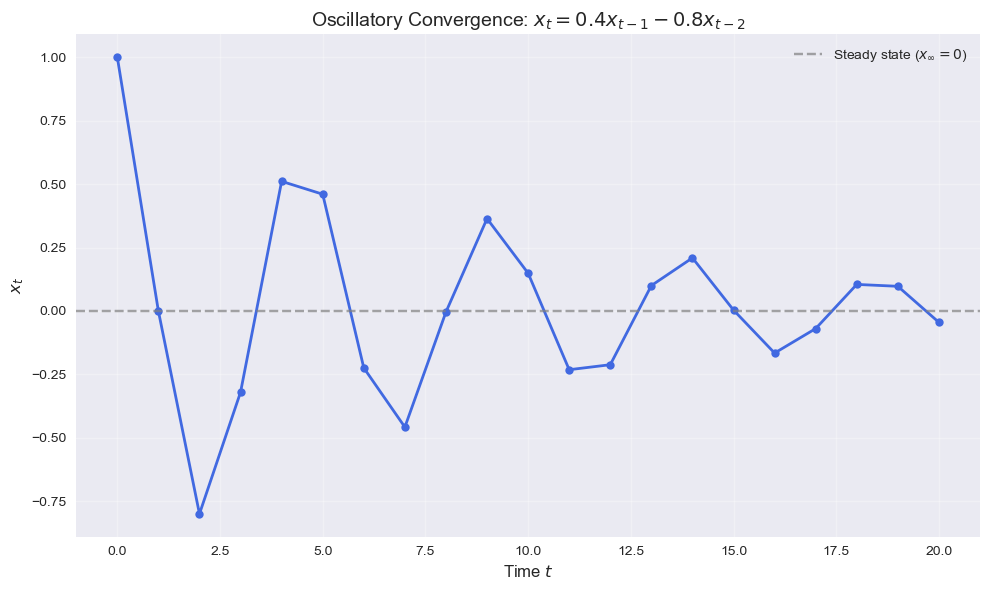

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from our solution
A = 1.026
r = 0.894
theta = 1.345
omega = 0.226

# Time steps
t = np.arange(0, 21)

# Compute x_t values
x_t = A * (r ** t) * np.cos(theta * t + omega)

# Create the plot
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))
plt.plot(t, x_t, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=6)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7, label='Steady state ($x_\infty = 0$)')
plt.title(r'Oscillatory Convergence: $x_t = 0.4x_{t-1} - 0.8x_{t-2}$', fontsize=14)
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel(r'$x_t$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

:::{tip}
Interpreting Complex Roots

r=∣b∣controls the speed of convergence/divergence:

* r<1 → oscillations shrink (damped)
* r>1 → oscillations grow (explosive)
* r=1 → oscillations persist forever (undamped)

θ controls the frequency of oscillations:

* θ=π/2 → 4-period cycle
* θ=π → 2-period cycle
* Other θ → irregular period lengths
:::

## From Scalars to Systems

So far, we've studied **single equations** where one variable evolves over time. But real economic systems involve **multiple interacting variables** simultaneously.

Consider a simple macroeconomic model:
- **Output** depends on last period's output (persistence)
- **Inflation** depends on last period's inflation (momentum)
- **Interest rates** depend on both output and inflation (policy rule)

These three variables evolve **together** — we can't solve for output without knowing inflation, and vice versa.

This leads us to **systems of difference equations**:

$$x_t = a_{11}x_{t-1} + a_{12}y_{t-1} + c_1$$
$$y_t = a_{21}x_{t-1} + a_{22}y_{t-1} + c_2$$

In matrix form, this becomes:

$$\mathbf{x}_t = A \mathbf{x}_{t-1} + \mathbf{c}$$

where $\mathbf{x}_t = \begin{bmatrix} x_t \\ y_t \end{bmatrix}$, $A = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix}$, and $\mathbf{c} = \begin{bmatrix} c_1 \\ c_2 \end{bmatrix}$.

The rest of this section works through concrete examples of such systems.

::: {.callout-note title="Key Idea"}
With more than one variable, difference equations must be solved **jointly**. The evolution of each variable depends on the others, so we move from scalar dynamics to **system dynamics**.
:::
## System of Linear Difference Equations I

Now we turn to systems where multiple variables evolve together. Consider a simple two-variable system:

$$x_t = 5x_{t-1} + 2y_{t-1} + 34$$
$$y_t = -3x_{t-1} + 0y_{t-1} - 6$$

Notice how $x_t$ depends on both $x_{t-1}$ and $y_{t-1}$, and $y_t$ also depends on both. These equations are **coupled** — we cannot solve one without the other.

:::{note}
**Why Systems Matter**
Real economic models rarely involve just one variable. Examples of coupled systems:
- **IS-LM model**: output and interest rates evolve together
- **Phillips curve**: inflation and unemployment interact
- **Growth models**: capital and technology co-evolve
- **Multi-sector models**: production in one sector affects another
:::

---

### Matrix Form

Writing systems in matrix form reveals their structure and allows us to use linear algebra tools.

Let:
$$\mathbf{x}_t = \begin{bmatrix} x_t \\ y_t \end{bmatrix}, \quad 
A = \begin{bmatrix} 5 & 2 \\ -3 & 0 \end{bmatrix}, \quad 
\mathbf{c} = \begin{bmatrix} 34 \\ -6 \end{bmatrix}$$

Our system becomes:

$$\mathbf{x}_t = A \mathbf{x}_{t-1} + \mathbf{c}$$

This is the **matrix analogue** of the scalar equation $x_t = a x_{t-1} + c$.

:::{tip}
**Parallel Structure**

| Scalar Case | System Case |
|-------------|-------------|
| $x_t = a x_{t-1} + c$ | $\mathbf{x}_t = A \mathbf{x}_{t-1} + \mathbf{c}$ |
| Steady state: $x^* = \frac{c}{1-a}$ | Steady state: $\mathbf{x}^* = (I - A)^{-1}\mathbf{c}$ |
| Characteristic root: $a$ | Characteristic roots: eigenvalues of $A$ |
| Stability: $|a| < 1$ | Stability: all $|\lambda_i| < 1$ |
:::

---

### Particular Solution (Steady State)

The steady state $\mathbf{x}^* = \begin{bmatrix} x^* \\ y^* \end{bmatrix}$ satisfies $\mathbf{x}^* = A\mathbf{x}^* + \mathbf{c}$, or:

$$(I - A)\mathbf{x}^* = \mathbf{c}$$

For our example:

$$I - A = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} - \begin{bmatrix} 5 & 2 \\ -3 & 0 \end{bmatrix} = \begin{bmatrix} -4 & -2 \\ 3 & 1 \end{bmatrix}$$

So we solve:

$$\begin{bmatrix} -4 & -2 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} x^* \\ y^* \end{bmatrix} = \begin{bmatrix} 34 \\ -6 \end{bmatrix}$$

This gives two equations:

$$-4x^* - 2y^* = 34$$
$$3x^* + y^* = -6$$

From the second: $y^* = -6 - 3x^*$. Substitute into the first:

$$-4x^* - 2(-6 - 3x^*) = 34$$
$$-4x^* + 12 + 6x^* = 34$$
$$2x^* = 22$$
$$x^* = 11$$

Then $y^* = -6 - 3(11) = -39$.

Thus the steady state is:
$$\mathbf{x}^* = \begin{bmatrix} 11 \\ -39 \end{bmatrix}$$

---

### Characteristic Equation and Eigenvalues

The system's dynamics are governed by the eigenvalues of $A$. To find them, solve:

$$\det(A - \lambda I) = 0$$

$$A - \lambda I = \begin{bmatrix} 5-\lambda & 2 \\ -3 & -\lambda \end{bmatrix}$$

The determinant is:

$$(5-\lambda)(-\lambda) - (2)(-3) = -5\lambda + \lambda^2 + 6 = \lambda^2 - 5\lambda + 6 = 0$$

Factor:

$$(\lambda - 2)(\lambda - 3) = 0$$

So the eigenvalues are:
$$\lambda_1 = 2,\quad \lambda_2 = 3$$

:::{important}
**Stability Check**
Since $|\lambda_1| = 2 > 1$ and $|\lambda_2| = 3 > 1$, **both eigenvalues lie outside the unit circle**. The system is **unstable** — deviations from steady state grow over time.
:::

---

### Eigenvectors

Eigenvectors tell us the **direction** of movement associated with each eigenvalue.

**For $\lambda_1 = 2$:** Solve $(A - 2I)\mathbf{v} = 0$

$$A - 2I = \begin{bmatrix} 3 & 2 \\ -3 & -2 \end{bmatrix}$$

This gives $3v_1 + 2v_2 = 0$. Choosing $v_1 = 2$ gives $v_2 = -3$. So:
$$\mathbf{v}_1 = \begin{bmatrix} 2 \\ -3 \end{bmatrix}$$

**For $\lambda_2 = 3$:** Solve $(A - 3I)\mathbf{v} = 0$

$$A - 3I = \begin{bmatrix} 2 & 2 \\ -3 & -3 \end{bmatrix}$$

This gives $2v_1 + 2v_2 = 0$, so $v_1 = -v_2$. Choosing $v_1 = 1$ gives $v_2 = -1$. So:
$$\mathbf{v}_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

:::{note}
**What Eigenvectors Mean**
- Each eigenvector points in a direction where the system moves in a straight line
- The associated eigenvalue tells you how fast (and in which direction) it moves along that line
- Any initial condition can be expressed as a combination of these directions
- The full solution is a weighted sum of movements along each eigen-direction
:::

---

### Complementary Function

The complementary solution is a linear combination of the eigen-motions:

$$\mathbf{x}_t^{(c)} = A_1 \mathbf{v}_1 \lambda_1^t + A_2 \mathbf{v}_2 \lambda_2^t$$

In our case:

$$\mathbf{x}_t^{(c)} = A_1 \begin{bmatrix} 2 \\ -3 \end{bmatrix} 2^t + A_2 \begin{bmatrix} 1 \\ -1 \end{bmatrix} 3^t$$

Writing component-wise:

$$x_t^{(c)} = 2A_1 \cdot 2^t + A_2 \cdot 3^t$$
$$y_t^{(c)} = -3A_1 \cdot 2^t - A_2 \cdot 3^t$$

---

### General Solution

Adding the particular solution:

$$x_t = 2A_1 \cdot 2^t + A_2 \cdot 3^t + 11$$
$$y_t = -3A_1 \cdot 2^t - A_2 \cdot 3^t - 39$$

---

### Definite Solution (with Initial Conditions)

Suppose initial conditions are $x_0 = 12$ and $y_0 = -41$.

At $t = 0$:

$$x_0 = 2A_1 + A_2 + 11 = 12 \quad \Rightarrow \quad 2A_1 + A_2 = 1$$
$$y_0 = -3A_1 - A_2 - 39 = -41 \quad \Rightarrow \quad -3A_1 - A_2 = -2$$

Solve the system:

Add the two equations: $(2A_1 + A_2) + (-3A_1 - A_2) = 1 + (-2)$, so $-A_1 = -1$, thus $A_1 = 1$.

Then $2(1) + A_2 = 1$, so $A_2 = -1$.

Therefore:
$$x_t = 2(1) \cdot 2^t + (-1) \cdot 3^t + 11 = 2^{t+1} - 3^t + 11$$
$$y_t = -3(1) \cdot 2^t - (-1) \cdot 3^t - 39 = -3 \cdot 2^t + 3^t - 39$$

---

### Verification

Check $t = 0$: $x_0 = 2 - 1 + 11 = 12$, $y_0 = -3 + 1 - 39 = -41$ ✓

Check $t = 1$: 
- From formulas: $x_1 = 4 - 3 + 11 = 12$, $y_1 = -6 + 3 - 39 = -42$
- From original equations: $x_1 = 5(12) + 2(-41) + 34 = 60 - 82 + 34 = 12$, $y_1 = -3(12) + 0(-41) - 6 = -36 - 6 = -42$ ✓

:::{important}
**Key Insight About System Stability**
With eigenvalues 2 and 3, both greater than 1, the system diverges. The $3^t$ term grows faster than the $2^t$ term, so eventually the $3^t$ component dominates. Unlike scalar equations where a single $a$ determines stability, **all eigenvalues must be inside the unit circle** for stability.
:::

## System of Linear Difference Equations II

Let's examine a system with richer dynamics — one eigenvalue inside the unit circle and one on the boundary.

Consider:

$$x_t = x_{t-1} + 2y_{t-1} + 4$$
$$y_t = -x_{t-1} - 2y_{t-1} + 1$$

In matrix form:
$$\mathbf{x}_t = A \mathbf{x}_{t-1} + \mathbf{c}$$

where:
$$A = \begin{bmatrix} 1 & 2 \\ -1 & -2 \end{bmatrix}, \quad \mathbf{c} = \begin{bmatrix} 4 \\ 1 \end{bmatrix}$$

---

### Particular Solution (Steady State)

Solve $(I - A)\mathbf{x}^* = \mathbf{c}$:

$$I - A = \begin{bmatrix} 0 & -2 \\ 1 & 3 \end{bmatrix}$$

So:
$$\begin{bmatrix} 0 & -2 \\ 1 & 3 \end{bmatrix} \begin{bmatrix} x^* \\ y^* \end{bmatrix} = \begin{bmatrix} 4 \\ 1 \end{bmatrix}$$

From the first row: $-2y^* = 4 \Rightarrow y^* = -2$.

From the second row: $x^* + 3(-2) = 1 \Rightarrow x^* - 6 = 1 \Rightarrow x^* = 7$.

Thus:
$$\mathbf{x}^* = \begin{bmatrix} 7 \\ -2 \end{bmatrix}$$

---

### Characteristic Equation

$$\det(A - \lambda I) = \det\left(\begin{bmatrix} 1-\lambda & 2 \\ -1 & -2-\lambda \end{bmatrix}\right) = 0$$

$$(1-\lambda)(-2-\lambda) - (2)(-1) = 0$$
$$-(1-\lambda)(2+\lambda) + 2 = 0$$
$$-(2 + \lambda - 2\lambda - \lambda^2) + 2 = 0$$
$$-2 - \lambda + 2\lambda + \lambda^2 + 2 = 0$$
$$\lambda^2 + \lambda = 0$$
$$\lambda(\lambda + 1) = 0$$

The eigenvalues are:
$$\lambda_1 = 0,\quad \lambda_2 = -1$$

:::{important}
**Stability Analysis**
- $\lambda_1 = 0$: This eigenvalue is inside the unit circle ($|0| < 1$). It represents a component that **dies out completely after one period** (since $0^t = 0$ for $t \ge 1$).
- $\lambda_2 = -1$: This eigenvalue is **on the unit circle** ($|-1| = 1$). It creates **persistent oscillations** that neither grow nor decay.

The system is **neutrally stable** — some components persist indefinitely.
:::

---

### Eigenvectors

**For $\lambda_1 = 0$:** Solve $A\mathbf{v} = 0$:

$$\begin{bmatrix} 1 & 2 \\ -1 & -2 \end{bmatrix} \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

This gives $v_1 + 2v_2 = 0$. Choose $v_2 = 1 \Rightarrow v_1 = -2$. So:
$$\mathbf{v}_1 = \begin{bmatrix} -2 \\ 1 \end{bmatrix}$$

**For $\lambda_2 = -1$:** Solve $(A + I)\mathbf{v} = 0$:

$$A + I = \begin{bmatrix} 2 & 2 \\ -1 & -1 \end{bmatrix}$$

This gives $2v_1 + 2v_2 = 0$, so $v_1 = -v_2$. Choose $v_1 = 1 \Rightarrow v_2 = -1$. So:
$$\mathbf{v}_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

---

### Complementary Function

$$\mathbf{x}_t^{(c)} = A_1 \begin{bmatrix} -2 \\ 1 \end{bmatrix} (0)^t + A_2 \begin{bmatrix} 1 \\ -1 \end{bmatrix} (-1)^t$$

For $t \ge 1$, the first term vanishes because $0^t = 0$. So:

$$x_t^{(c)} = A_2 (-1)^t$$
$$y_t^{(c)} = -A_2 (-1)^t$$

The $0^t$ term affects only the $t = 0$ initial condition.

---

### General Solution

Adding the particular solution:

$$x_t = A_2 (-1)^t + 7 \quad (\text{for } t \ge 1)$$
$$y_t = -A_2 (-1)^t - 2 \quad (\text{for } t \ge 1)$$

For $t = 0$, we have an extra term from the zero eigenvalue:

$$x_0 = -2A_1 + A_2 + 7$$
$$y_0 = A_1 - A_2 - 2$$

---

### Definite Solution (with Initial Conditions)

Suppose $x_0 = 6$ and $y_0 = 0$. Then:

$$-2A_1 + A_2 + 7 = 6 \quad \Rightarrow \quad -2A_1 + A_2 = -1$$
$$A_1 - A_2 - 2 = 0 \quad \Rightarrow \quad A_1 - A_2 = 2$$

Add the two equations: $(-2A_1 + A_2) + (A_1 - A_2) = -1 + 2$, so $-A_1 = 1$, thus $A_1 = -1$.

Then $A_1 - A_2 = 2 \Rightarrow -1 - A_2 = 2 \Rightarrow -A_2 = 3 \Rightarrow A_2 = -3$.

Therefore, for all $t \ge 0$:

$$x_t = -2(-1)(0)^t + (-3)(-1)^t + 7 = 2 \cdot 0^t - 3(-1)^t + 7$$
$$y_t = (-1)(0)^t - (-3)(-1)^t - 2 = -0^t + 3(-1)^t - 2$$

For $t = 0$: $x_0 = 2(1) - 3(1) + 7 = 6$, $y_0 = -1 + 3(1) - 2 = 0$ ✓

For $t \ge 1$ (since $0^t = 0$):

$$x_t = -3(-1)^t + 7$$
$$y_t = 3(-1)^t - 2$$

---

### Interpretation

Let's write out the first few terms for $t \ge 1$:

| $t$ | $(-1)^t$ | $x_t$ | $y_t$ |
|-----|----------|-------|-------|
| 1 | -1 | $(-3)(-1) + 7 = 10$ | $3(-1) - 2 = -5$ |
| 2 | 1 | $(-3)(1) + 7 = 4$ | $3(1) - 2 = 1$ |
| 3 | -1 | $(-3)(-1) + 7 = 10$ | $3(-1) - 2 = -5$ |
| 4 | 1 | $(-3)(1) + 7 = 4$ | $3(1) - 2 = 1$ |

Notice the pattern:
- $x_t$ alternates between 10 and 4
- $y_t$ alternates between -5 and 1
- The oscillations **persist forever** (neither grow nor decay)

:::{note}
**Why Persistent Oscillations?**
The eigenvalue $\lambda_2 = -1$ lies exactly on the unit circle ($|\lambda| = 1$). This creates a **2-cycle**: the system alternates between two states indefinitely.

In economic terms, this could represent:
- **Seasonal cycles** that repeat predictably
- **Alternating policy regimes** (e.g., expansion/contraction)
- **Inventory cycles** in simple production models
:::

---

### Summary: Eigenvalues and System Behavior

| Eigenvalue magnitude | Behavior | Example |
|---------------------|----------|---------|
| $|\lambda| < 1$ | Converges to zero | $\lambda = 0.5$ |
| $|\lambda| > 1$ | Diverges to infinity | $\lambda = 2$ |
| $\lambda = 1$ | Constant non-zero | $\lambda = 1$ |
| $\lambda = -1$ | 2-cycle (alternating) | $\lambda = -1$ |
| Complex with $r < 1$ | Oscillatory convergence | $r = 0.9$ |
| Complex with $r > 1$ | Oscillatory divergence | $r = 1.1$ |
| Complex with $r = 1$ | Persistent oscillations | $r = 1$, $\theta = \pi/2$ |

:::{tip}
**Economic Interpretation**
Systems like this often appear when one variable adjusts quickly while another evolves more gradually. The eigenvalues capture these different speeds of adjustment:

- **Fast adjustment** → eigenvalues close to zero
- **Slow adjustment** → eigenvalues close to one
- **Cyclical behavior** → complex eigenvalues
- **Instability** → eigenvalues outside the unit circle
:::

---

## Summary and Next Steps

We've covered a lot of ground. Let's recap the key ideas:

### First-Order Equations

- **Form:** $x_t = a x_{t-1} + c$
- **Steady state:** $x^* = c/(1-a)$ for $a \neq 1$
- **Stability condition:** $|a| < 1$
- **Behavior:** Monotonic if $a > 0$, oscillatory if $a < 0$

### Second-Order Equations

- **Form:** $x_t = a x_{t-1} + b x_{t-2} + c$
- **Characteristic equation:** $k^2 - a k - b = 0$
- **Three cases:** Real distinct, repeated, or complex roots
- **Stability condition:** All roots inside unit circle

### Systems of Equations

- **Form:** $\mathbf{x}_t = A \mathbf{x}_{t-1} + \mathbf{c}$
- **Steady state:** $\mathbf{x}^* = (I-A)^{-1}\mathbf{c}$ (when invertible)
- **Eigenvalues determine dynamics**
- **Stability condition:** All eigenvalues $|\lambda_i| < 1$

### Key Insights

1. **The unit circle is the boundary between stability and instability**
2. **Negative coefficients create oscillations**
3. **Complex eigenvalues create damped or explosive cycles**
4. **Systems can have mixed stability** (some components stable, others not)
5. **Eigenvectors reveal the directions of motion**

---

## Practice Problems

Try these on your own:

**1.** For $x_t = 0.8x_{t-1} + 20$ with $x_0 = 100$:
   - Find the steady state
   - Is the system stable?
   - Calculate $x_1$, $x_2$, $x_3$

**2.** For $x_t = -0.6x_{t-1} + 40$ with $x_0 = 30$:
   - Find the steady state
   - Is the path oscillatory? Why?
   - Calculate the first 4 terms

**3.** For $x_t = 1.2x_{t-1} - 0.2x_{t-2}$ (homogeneous):
   - Find the characteristic roots
   - Is the system stable?
   - What type of behavior do you expect?

**4.** For the system:
   $$x_t = 0.5x_{t-1} + 0.2y_{t-1}$$
   $$y_t = 0.1x_{t-1} + 0.6y_{t-1}$$
   - Write in matrix form
   - Find the eigenvalues (approximately)
   - Is the system stable?

---

### Further Reading

- **Elaydi, S. (2005).** *An Introduction to Difference Equations*. Springer. (Comprehensive theory)
- **Gandolfo, G. (2009).** *Economic Dynamics*. Springer. (Applications in economics)
- **Shone, R. (2002).** *Economic Dynamics: Phase Diagrams and Their Economic Application*. Cambridge University Press. (Emphasis on phase diagrams)

---

### What's Next?

You might want to explore:
- **Nonlinear difference equations** (much richer behavior, including chaos)
- **Stochastic difference equations** (adding random shocks)
- **Higher-order systems** (three or more variables)
- **Control theory** (how to steer a system toward a target)

---

:::{important}
**Final Note**
The code in this notebook is designed to be reusable. You can modify parameters, initial conditions, and coefficients to explore your own difference equations. Experimentation is the best way to build intuition!
:::

### Problem Set

Work through these problems to solidify your understanding. Answers are provided at the end.

---

#### Section A: First-Order Equations

**A1.** For $x_t = 0.7x_{t-1} + 15$ with $x_0 = 50$:
   a) Find the steady state $x^*$
   b) Is the system stable? Why?
   c) Calculate $x_1$, $x_2$, $x_3$ by hand
   d) Write the general solution
   e) Find the definite solution

**A2.** For $x_t = -0.4x_{t-1} + 28$ with $x_0 = 10$:
   a) Find the steady state
   b) Will the path be monotonic or oscillatory? Explain.
   c) Is the system stable? Why?
   d) Calculate $x_1$ through $x_4$
   e) Find the definite solution

**A3.** For $x_t = 1.5x_{t-1} - 10$ with $x_0 = 20$:
   a) Find the steady state
   b) What happens if $x_0 = 20$? If $x_0 = 21$?
   c) Explain why this steady state is called "unstable"

**A4.** For $x_t = -1.2x_{t-1} + 44$ with $x_0 = 20$:
   a) Find the steady state
   b) Describe the path (monotonic/oscillatory, convergent/divergent)
   c) Calculate $x_1$ through $x_4$
   d) What pattern do you observe in the signs of the values?

---

#### Section B: Second-Order Equations

**B1.** For $x_t = 0.9x_{t-1} - 0.2x_{t-2}$ (homogeneous):
   a) Find the characteristic equation
   b) Find the characteristic roots
   c) Is the system stable?
   d) Write the general solution form

**B2.** For $x_t = 0.5x_{t-1} + 0.5x_{t-2} + 10$:
   a) Find the steady state
   b) Find the characteristic roots
   c) Which case applies (real distinct, repeated, or complex)?
   d) Is the system stable?
   e) If $x_0 = 15$ and $x_1 = 14$, find the definite solution (set up the equations but you may leave $A$, $B$ unsolved)

**B3.** For $x_t = 0.2x_{t-1} - 0.8x_{t-2}$:
   a) Find the discriminant. Is it positive, zero, or negative?
   b) Find $r$ and $\theta$ (to 3 decimal places)
   c) Write the general solution form
   d) Is the system stable? Why?

**B4.** For $x_t - 6x_{t-1} + 9x_{t-2} = 5$ with $x_0 = 2$, $x_1 = 3$:
   a) Find the steady state
   b) Find the characteristic roots. What's special about them?
   c) Which case applies?
   d) Write the general solution form
   e) Find the definite solution (solve for $A$ and $B$)

---

#### Section C: Systems of Equations

**C1.** Consider the system:
   $$x_t = 0.5x_{t-1} + 0.3y_{t-1}$$
   $$y_t = 0.2x_{t-1} + 0.6y_{t-1}$$
   a) Write the system in matrix form $\mathbf{x}_t = A\mathbf{x}_{t-1}$
   b) Find the eigenvalues of $A$
   c) Is the system stable? Why?
   d) Find the eigenvectors (one for each eigenvalue)

**C2.** Consider the system:
   $$x_t = 2x_{t-1} + y_{t-1} + 3$$
   $$y_t = x_{t-1} + 2y_{t-1} + 3$$
   a) Write in matrix form $\mathbf{x}_t = A\mathbf{x}_{t-1} + \mathbf{c}$
   b) Find the steady state $\mathbf{x}^*$
   c) Find the eigenvalues of $A$
   d) Is the system stable? Explain how you know without calculating explicit solutions

**C3.** Consider the system:
   $$x_t = x_{t-1} - y_{t-1} + 2$$
   $$y_t = 2x_{t-1} - 2y_{t-1} + 4$$
   a) Find $I - A$ and determine if a unique steady state exists
   b) If a unique steady state exists, find it
   c) Find the eigenvalues of $A$
   d) Based on the eigenvalues, describe the long-run behavior of the system

**C4.** (Challenge) For the system:
   $$x_t = 0.6x_{t-1} - 1.2y_{t-1}$$
   $$y_t = 0.3x_{t-1} + 0.4y_{t-1}$$
   a) Find the eigenvalues (they will be complex)
   b) Compute $r$ and $\theta$
   c) Describe the behavior (oscillatory? convergent/divergent?)
   d) What economic interpretation might such a system have?

---

#### Section D: Mixed and Applied Problems

**D1.** A simple cobweb model of supply and demand:
   - Demand: $Q_t^d = a - bP_t$
   - Supply: $Q_t^s = c + dP_{t-1}$ (supply depends on previous period's price)
   - Equilibrium: $Q_t^d = Q_t^s$
   
   a) Derive the difference equation for $P_t$
   b) What are $a$, $b$, $c$, $d$? What signs should they have?
   c) Find the steady state price $P^*$
   d) Under what condition is the market stable?
   e) If $a = 100$, $b = 2$, $c = 20$, $d = 3$, is the market stable?

**D2.** A tax-and-transfer model:
   - National income: $Y_t = C_t + I_t + G_t$
   - Consumption: $C_t = a + b(Y_{t-1} - T_{t-1})$
   - Taxes: $T_t = tY_t$ (proportional tax)
   - Investment and government spending are constant: $I_t = I$, $G_t = G$
   
   a) Derive a first-order difference equation for $Y_t$
   b) Find the steady state $Y^*$
   c) What condition ensures stability?
   d) If $a = 50$, $b = 0.8$, $t = 0.25$, $I = 100$, $G = 150$, find $Y^*$

**D3.** A multiplier-accelerator model (second-order):
   - National income: $Y_t = C_t + I_t + G$
   - Consumption: $C_t = a + bY_{t-1}$
   - Investment: $I_t = v(Y_{t-1} - Y_{t-2})$ (accelerator principle)
   - $G$ is constant government spending
   
   a) Derive the second-order difference equation for $Y_t$
   b) Find the steady state $Y^*$
   c) For $a = 50$, $b = 0.6$, $v = 0.5$, $G = 100$, find the characteristic roots
   d) Is the system stable? Will it oscillate?

---

### Answer Key

#### A1. 
a) $x^* = 15 / (1 - 0.7) = 15 / 0.3 = 50$
b) Yes, $|a| = 0.7 < 1$, so stable
c) $x_1 = 0.7(50) + 15 = 50$, $x_2 = 0.7(50) + 15 = 50$, $x_3 = 50$ (already at steady state)
d) $x_t = A(0.7)^t + 50$
e) $A = x_0 - 50 = 50 - 50 = 0$, so $x_t = 50$ (constant)

#### A2.
a) $x^* = 28 / (1 - (-0.4)) = 28 / 1.4 = 20$
b) Oscillatory because $a = -0.4 < 0$
c) Yes, $|a| = 0.4 < 1$, so stable
d) $x_1 = -0.4(10) + 28 = 24$, $x_2 = -0.4(24) + 28 = 18.4$, $x_3 = -0.4(18.4) + 28 = 20.64$, $x_4 = -0.4(20.64) + 28 = 19.744$
e) $x_t = (x_0 - x^*)(-0.4)^t + x^* = (10 - 20)(-0.4)^t + 20 = -10(-0.4)^t + 20$

#### A3.
a) $x^* = (-10) / (1 - 1.5) = (-10) / (-0.5) = 20$
b) If $x_0 = 20$, it stays at 20. If $x_0 = 21$, $x_1 = 1.5(21) - 10 = 21.5$, $x_2 = 1.5(21.5) - 10 = 22.25$, diverging upward.
c) Unstable because $|a| = 1.5 > 1$; any deviation grows.

#### A4.
a) $x^* = 44 / (1 - (-1.2)) = 44 / 2.2 = 20$
b) Oscillatory (negative $a$) and divergent ($|a| = 1.2 > 1$)
c) $x_1 = -1.2(20) + 44 = 20$, $x_2 = -1.2(20) + 44 = 20$, $x_3 = 20$, $x_4 = 20$ — wait, $x_0 = 20$ is exactly the steady state! Let's instead assume $x_0 = 21$: $x_1 = -1.2(21) + 44 = 18.8$, $x_2 = -1.2(18.8) + 44 = 21.44$, $x_3 = -1.2(21.44) + 44 = 18.272$, $x_4 = -1.2(18.272) + 44 = 22.0736$ (oscillating with increasing amplitude)
d) Signs alternate (positive → negative → positive → ...)

#### B1.
a) $k^2 - 0.9k + 0.2 = 0$
b) $k = [0.9 \pm \sqrt{0.81 - 0.8}] / 2 = [0.9 \pm 0.1] / 2$, so $k_1 = 0.5$, $k_2 = 0.4$
c) Yes, both roots $< 1$
d) $x_t = A(0.5)^t + B(0.4)^t$

#### B2.
a) $x_\infty = 10 / (1 - 0.5 - 0.5) = 10 / 0$ → undefined (no finite steady state; system has a unit root)
b) $k^2 - 0.5k - 0.5 = 0$, $k = [0.5 \pm \sqrt{0.25 + 2}]/2 = [0.5 \pm \sqrt{2.25}]/2 = [0.5 \pm 1.5]/2$, so $k_1 = 1$, $k_2 = -0.5$
c) Real and distinct
d) Not stable because $k_1 = 1$ (unit root)
e) $x_t = A(1)^t + B(-0.5)^t + \text{?}$ — but with $a+b=1$, need special treatment (particular solution takes form $x_p = \alpha t$). Beyond scope of basic problem.

#### B3.
a) $a^2 + 4b = (0.2)^2 + 4(-0.8) = 0.04 - 3.2 = -3.16 < 0$ (negative)
b) $r = \sqrt{|b|} = \sqrt{0.8} \approx 0.894$, $\cos\theta = a/(2r) = 0.2 / 1.788 \approx 0.112$, $\theta = \arccos(0.112) \approx 1.458$ rad
c) $x_t = A (0.894)^t \cos(1.458t + \omega)$
d) Stable because $r = 0.894 < 1$

#### B4.
a) Rewrite as $x_t = 6x_{t-1} - 9x_{t-2} + 5$. Then $x_\infty = 5 / (1 - 6 + 9) = 5 / 4 = 1.25$
b) $k^2 - 6k + 9 = (k-3)^2 = 0$, so repeated root $k = 3$
c) Repeated root case
d) $x_t = (A + Bt)(3)^t + 1.25$
e) At $t=0$: $A + 1.25 = 2 \Rightarrow A = 0.75$. At $t=1$: $(0.75 + B)(3) + 1.25 = 3 \Rightarrow 2.25 + 3B + 1.25 = 3 \Rightarrow 3.5 + 3B = 3 \Rightarrow 3B = -0.5 \Rightarrow B = -1/6$. So $x_t = (0.75 - t/6)(3)^t + 1.25$

#### C1.
a) $\mathbf{x}_t = \begin{bmatrix} 0.5 & 0.3 \\ 0.2 & 0.6 \end{bmatrix} \mathbf{x}_{t-1}$
b) $\det(A - \lambda I) = (0.5-\lambda)(0.6-\lambda) - (0.3)(0.2) = \lambda^2 - 1.1\lambda + 0.3 - 0.06 = \lambda^2 - 1.1\lambda + 0.24 = 0$, $\lambda = [1.1 \pm \sqrt{1.21 - 0.96}]/2 = [1.1 \pm 0.5]/2$, so $\lambda_1 = 0.8$, $\lambda_2 = 0.3$
c) Stable because both eigenvalues $< 1$
d) For $\lambda = 0.8$: $(A - 0.8I) = \begin{bmatrix} -0.3 & 0.3 \\ 0.2 & -0.2 \end{bmatrix}$, eigenvector $\mathbf{v}_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$. For $\lambda = 0.3$: $(A - 0.3I) = \begin{bmatrix} 0.2 & 0.3 \\ 0.2 & 0.3 \end{bmatrix}$, eigenvector $\mathbf{v}_2 = \begin{bmatrix} -3 \\ 2 \end{bmatrix}$.

#### C2.
a) $\mathbf{x}_t = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} \mathbf{x}_{t-1} + \begin{bmatrix} 3 \\ 3 \end{bmatrix}$
b) $I - A = \begin{bmatrix} -1 & -1 \\ -1 & -1 \end{bmatrix}$, which is singular (rows linearly dependent). No unique steady state exists. The system has a continuum of steady states along $x + y = -3$.
c) $\det(A - \lambda I) = (2-\lambda)^2 - 1 = \lambda^2 - 4\lambda + 4 - 1 = \lambda^2 - 4\lambda + 3 = 0$, so $\lambda_1 = 1$, $\lambda_2 = 3$
d) Not stable — one eigenvalue is 1 (unit root) and another is 3 (>1)

#### C3.
a) $A = \begin{bmatrix} 1 & -1 \\ 2 & -2 \end{bmatrix}$, $I - A = \begin{bmatrix} 0 & 1 \\ -2 & 3 \end{bmatrix}$, determinant $= 0(3) - 1(-2) = 2 \neq 0$, so unique steady state exists
b) Solve $(I-A)\mathbf{x}^* = \mathbf{c}$: $\begin{bmatrix} 0 & 1 \\ -2 & 3 \end{bmatrix} \begin{bmatrix} x^* \\ y^* \end{bmatrix} = \begin{bmatrix} 2 \\ 4 \end{bmatrix}$. First row: $y^* = 2$. Second row: $-2x^* + 3(2) = 4 \Rightarrow -2x^* = -2 \Rightarrow x^* = 1$. So $\mathbf{x}^* = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$
c) $\det(A - \lambda I) = (1-\lambda)(-2-\lambda) - (-1)(2) = (1-\lambda)(-2-\lambda) + 2 = -2 - \lambda + 2\lambda + \lambda^2 + 2 = \lambda^2 + \lambda = \lambda(\lambda+1) = 0$, so $\lambda_1 = 0$, $\lambda_2 = -1$
d) $\lambda_1 = 0$ (stable — dies out), $\lambda_2 = -1$ (on unit circle — persistent 2-cycle). System is neutrally stable with persistent oscillations.

#### C4.
a) $A = \begin{bmatrix} 0.6 & -1.2 \\ 0.3 & 0.4 \end{bmatrix}$, $\det(A - \lambda I) = (0.6-\lambda)(0.4-\lambda) - (-1.2)(0.3) = 0.24 - 0.6\lambda - 0.4\lambda + \lambda^2 + 0.36 = \lambda^2 - \lambda + 0.6 = 0$, $\lambda = [1 \pm \sqrt{1 - 2.4}]/2 = [1 \pm \sqrt{-1.4}]/2 = 0.5 \pm 0.5916i$
b) $r = \sqrt{0.5^2 + 0.5916^2} = \sqrt{0.25 + 0.35} = \sqrt{0.6} \approx 0.775$, $\cos\theta = 0.5 / 0.775 \approx 0.645$, $\theta = \arccos(0.645) \approx 0.87$ rad
c) Oscillatory (complex eigenvalues) and convergent ($r = 0.775 < 1$). The system spirals in toward the steady state (which is the origin since $c=0$).
d) Possible interpretations: predator-prey cycles, business cycles with diminishing amplitude, or two interacting economic variables with negative feedback.

#### D1.
a) $a - bP_t = c + dP_{t-1} \Rightarrow -bP_t = c + dP_{t-1} - a \Rightarrow P_t = -\frac{d}{b}P_{t-1} + \frac{a-c}{b}$
b) $a > 0$ (demand intercept), $b > 0$ (demand slope), $c \ge 0$ (minimum supply), $d > 0$ (supply slope)
c) $P^* = \frac{a-c}{b+d}$
d) $|d/b| < 1 \Rightarrow d < b$ (supply response less than demand response)
e) $d = 3$, $b = 2$, $3 < 2$? No — market is unstable!

#### D2.
a) $Y_t = a + b(Y_{t-1} - tY_{t-1}) + I + G = a + b(1-t)Y_{t-1} + I + G$
b) $Y^* = [a + I + G] / [1 - b(1-t)]$
c) Stability requires $|b(1-t)| < 1$
d) $b(1-t) = 0.8(0.75) = 0.6 < 1$ (stable). $Y^* = (50 + 100 + 150) / (1 - 0.6) = 300 / 0.4 = 750$

#### D3.
a) $Y_t = a + bY_{t-1} + v(Y_{t-1} - Y_{t-2}) + G = a + (b+v)Y_{t-1} - vY_{t-2} + G$
b) $Y^* = (a + G) / (1 - b)$ (since $v$ terms cancel in steady state)
c) Parameters: $a=50$, $b=0.6$, $v=0.5$, $G=100$. Then $Y^* = (50+100)/(1-0.6) = 150/0.4 = 375$. The difference equation: $Y_t = 50 + (0.6+0.5)Y_{t-1} - 0.5Y_{t-2} + 100 = 1.1Y_{t-1} - 0.5Y_{t-2} + 150$. Characteristic equation: $k^2 - 1.1k + 0.5 = 0$, discriminant $= 1.21 - 2 = -0.79$, so complex roots. $r = \sqrt{0.5} \approx 0.707$, $\cos\theta = 1.1/(2 \times 0.707) \approx 0.778$, $\theta \approx 0.68$ rad.
d) Stable because $r = 0.707 < 1$, and oscillatory because roots are complex.

---

:::{tip}
**Want more practice?**
- Change the initial conditions and re-solve
- Modify parameters to see how stability conditions change
- Graph the solutions using the code from this notebook
- Try to find real-world economic data and fit a difference equation to it
:::